# Bank Marketing — Predicting Term Deposit Subscription

CS417 Introduction to Data Mining — Project Notebook.

The goal of this project is to predict whether a bank client will subscribe to a term deposit (`y` = yes / no).

We use the Bank Marketing dataset from the UCI Machine Learning Repository (ID 222), which contains around 45,000 clients of a Portuguese bank and 16 attributes.

The dataset records the results of direct phone marketing campaigns: who was contacted, what we know about the client, and whether they ended up subscribing.

### Students:
Abdalkarim Alaraj - 240302361 

Muhamed Maglic - 240302066 

Hamza Hubanic - 240302089


## 1. What we will do

The project has the following steps:

1. Load and understand the dataset
2. Clean and preprocess the data
3. Explore and analyse the data with plots (EDA)
4. Train five classification models
5. Try a simple K-Means clustering
6. Look at feature importance
7. Compare the models and write conclusions

The five models are:

- Decision Tree
- Naive Bayes
- k-Nearest Neighbors (k-NN)
- Random Forest
- Logistic Regression

## 2. Setup

The next cell imports everything used in the notebook and sets a random seed so the results are reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Clean plotting style
sns.set_style("whitegrid")
PALETTE = "viridis"

# Remove warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## 3. Load the dataset

We use the `ucimlrepo` package to download the dataset directly from UCI. After loading, we combine the features and the target into one DataFrame and save a local CSV copy so we don't have to re-download every time.

In [2]:
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

df = pd.concat([X, y], axis=1)
df.to_csv("bank_marketing.csv", index=False)

print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## 4. Understand the dataset

Before any cleaning, we look at the structure of the data: the column types, the meaning of each feature, the summary statistics, and the target distribution.

The 16 input attributes can be grouped into three categories.

**Client information** — what we know about the client:

| Feature | Type | Description |
|---|---|---|
| `age` | numeric | Client age in years |
| `job` | categorical | Type of job (admin, technician, retired, …) |
| `marital` | categorical | Marital status |
| `education` | categorical | Education level |
| `default` | categorical | Has credit in default? |
| `balance` | numeric | Average yearly balance (euros) |
| `housing` | categorical | Has a housing loan? |
| `loan` | categorical | Has a personal loan? |

**Last contact of the current campaign** — information about the most recent call:

| Feature | Type | Description |
|---|---|---|
| `contact` | categorical | Communication type (cellular, telephone) |
| `day_of_week` | numeric | Last contact day of the month |
| `month` | categorical | Last contact month |
| `duration` | numeric | Last contact duration in seconds |

**Campaign history** — past contacts with this client:

| Feature | Type | Description |
|---|---|---|
| `campaign` | numeric | Number of contacts during this campaign |
| `pdays` | numeric | Days since last contact in a previous campaign (`-1` = never) |
| `previous` | numeric | Number of contacts before this campaign |
| `poutcome` | categorical | Outcome of the previous campaign |

The **target** is `y`, which is `yes` if the client subscribed to a term deposit and `no` otherwise.

### 4.1 Column types and summary statistics

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 4.2 Categorical columns

We list the unique values in each categorical column. Some columns (`job`, `education`, `contact`, `poutcome`) contain missing values, which the `ucimlrepo` loader represents as `NaN`. We will deal with these during preprocessing.

In [5]:
for col in df.select_dtypes(include="object").columns:
    print(col, "->", df[col].unique())

job -> ['management' 'technician' 'entrepreneur' 'blue-collar' nan 'retired'
 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid' 'student']
marital -> ['married' 'single' 'divorced']
education -> ['tertiary' 'secondary' nan 'primary']
default -> ['no' 'yes']
housing -> ['yes' 'no']
loan -> ['no' 'yes']
contact -> [nan 'cellular' 'telephone']
month -> ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome -> [nan 'failure' 'other' 'success']
y -> ['no' 'yes']


### 4.3 Target distribution

The target tells us whether the client subscribed. The dataset is **imbalanced**: most clients did not subscribe.

This is something to keep in mind later, because a model that always predicts "no" would already get a high accuracy without really learning anything. That is why we will also report precision, recall, F1, and ROC-AUC.

y
no     39922
yes     5289
Name: count, dtype: int64

Percentages y
no     88.3
yes    11.7
Name: proportion, dtype: float64


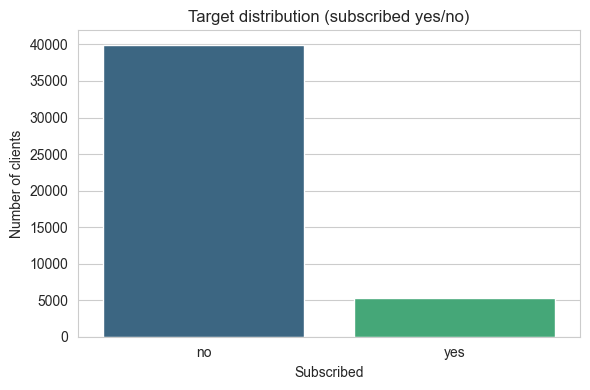

In [6]:
print(df["y"].value_counts())
print()
print('Percentages', df["y"].value_counts(normalize=True).round(3)*100)

plt.figure(figsize=(6, 4))
sns.countplot(x="y", data=df, palette=PALETTE)
plt.title("Target distribution (subscribed yes/no)")
plt.xlabel("Subscribed")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

## 5. Preprocessing

We now clean the data step by step.

### 5.1 Encode the target

We map `yes` to 1 and `no` to 0 so the target becomes numeric.

In [7]:
df["y"] = df["y"].map({"yes": 1, "no": 0})
df["y"].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

### 5.2 Drop the `duration` column

`duration` is the length of the last call in seconds. It is only known after the call ends, so it cannot be used to decide who to call. We drop it.

In [8]:
if "duration" in df.columns:
    df = df.drop(columns=["duration"])
print("Columns now:", df.shape[1])

Columns now: 16


### 5.3 Handle `pdays = -1`

In `pdays`, the value `-1` means the client was never contacted before. This is not a real number of days, so we replace it with `0` and add a new column that flags whether the client was contacted before. This keeps the information instead of losing it.

In [9]:
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)

df[["pdays", "previous", "was_contacted_before"]].head()

,pdays,previous,was_contacted_before
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


### 5.4 Missing values

A few columns have missing values, shown as `NaN` (for example `contact` and `poutcome` are missing for many clients who were never part of a previous campaign). We check how many missing values each column has below. We do not drop these rows. When we apply one-hot encoding later with `pd.get_dummies`, a row whose category is `NaN` simply gets `0` in all the dummy columns for that feature, so the information that the value was missing is handled without deleting any client.

In [10]:
# Count missing values (NaN) per column
missing = df.isnull().sum()
print(missing[missing > 0])

job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


### 5.5 Remove duplicate rows

In [11]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicates: 16
Shape after removing duplicates: (45195, 17)


### 5.6 Outliers

We look at the numeric columns with boxplots. We do **not** remove outliers, because most of them are real clients (very high balance, many contacts), not errors.

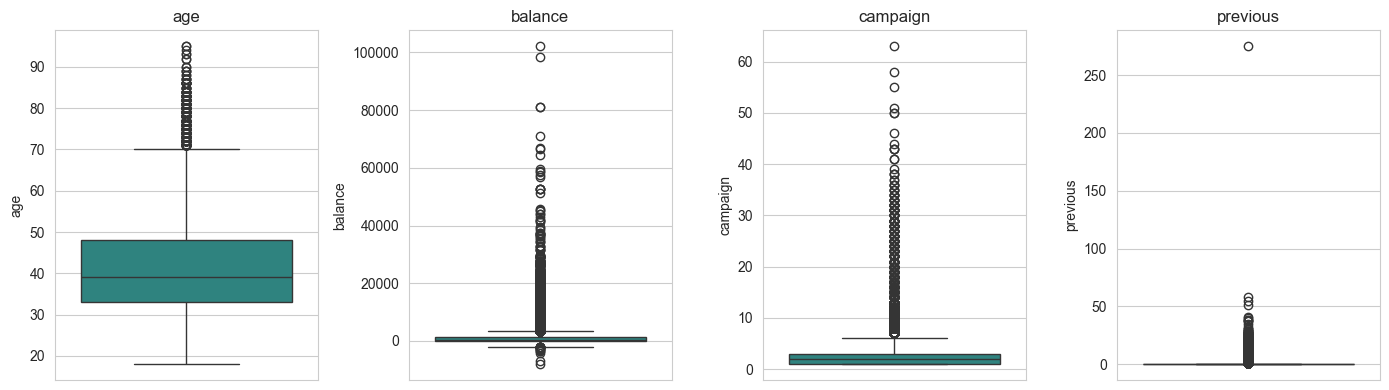

In [12]:
num_cols_check = ["age", "balance", "campaign", "previous"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, num_cols_check):
    sns.boxplot(y=df[col], ax=ax, color="#21918c")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 5.7 One-hot encoding

We turn the categorical columns into numeric columns using one-hot encoding. This is needed for Logistic Regression, k-NN, and Naive Bayes, which all work with numbers.

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (45195, 39)


,age,balance,day_of_week,campaign,pdays,previous,y,was_contacted_before,job_blue-collar,job_entrepreneur,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
0,58,2143,5,1,0,0,0,0,False,False,...,False,False,False,False,True,False,False,False,False,False
1,44,29,5,1,0,0,0,0,False,False,...,False,False,False,False,True,False,False,False,False,False
2,33,2,5,1,0,0,0,0,False,True,...,False,False,False,False,True,False,False,False,False,False
3,47,1506,5,1,0,0,0,0,True,False,...,False,False,False,False,True,False,False,False,False,False
4,33,1,5,1,0,0,0,0,False,False,...,False,False,False,False,True,False,False,False,False,False


### 5.8 Train/test split

We split the data into 75% training and 25% testing. We use `stratify=y` so both sets keep the same proportion of subscribers.

In [14]:
X = df_encoded.drop(columns=["y"])
y = df_encoded["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (33896, 38)
Test: (11299, 38)


### 5.9 Scaling

We scale the numeric features. This is important for k-NN and Logistic Regression because they depend on the size of the values. Decision Trees and Random Forests do not need scaling, but it does not hurt them either.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Shape:", X_train_scaled.shape)

Scaling done. Shape: (33896, 38)


## 6. Exploratory Data Analysis (EDA)

Before training models, we look at the data with plots to understand the main patterns.

### 6.1 Numeric distributions

We look at how the main numeric features are distributed. Most of them are right-skewed, meaning a few very high values stretch the tail.

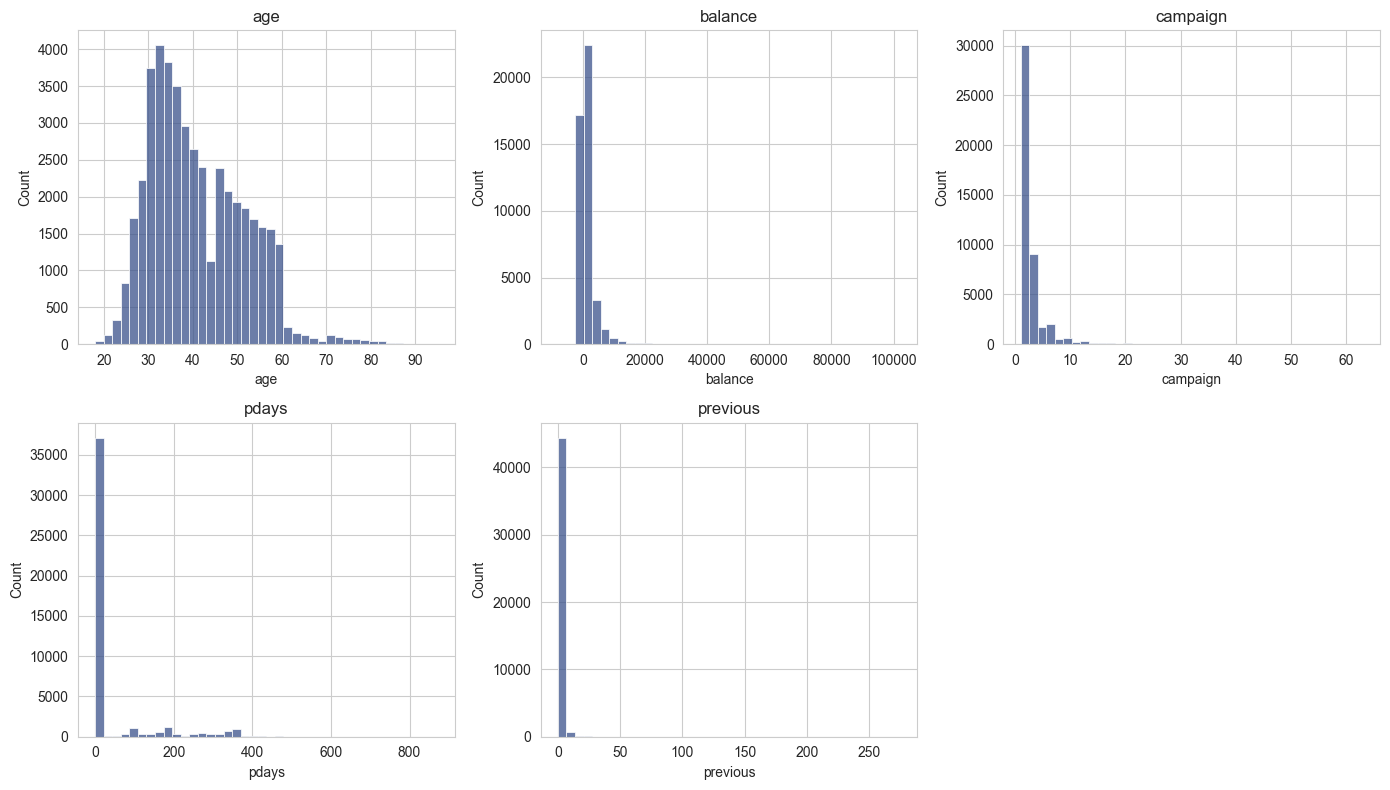

In [16]:
num_cols = ["age", "balance", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#3b528b")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

### 6.2 Subscription rate by job

Some jobs subscribe more often than others. Students and retired clients tend to be above average.

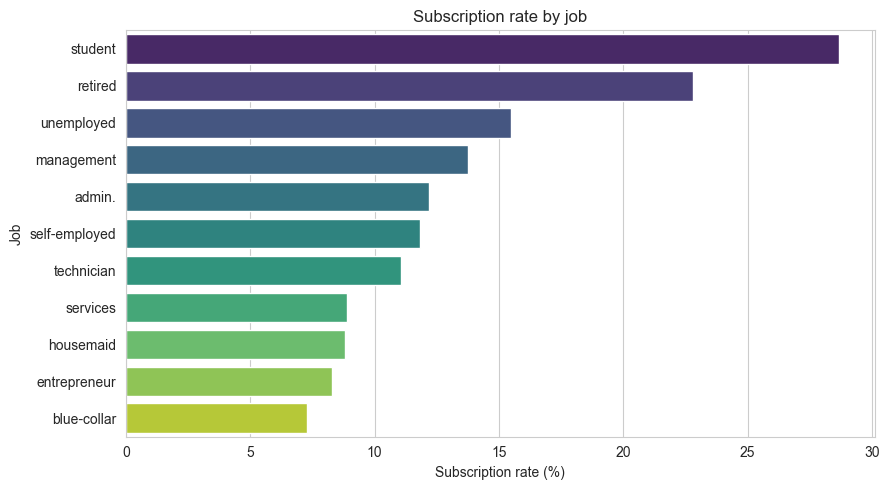

In [17]:
job_rate = df.groupby("job")["y"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 5))
sns.barplot(x=job_rate.values, y=job_rate.index, palette=PALETTE)
plt.xlabel("Subscription rate (%)")
plt.ylabel("Job")
plt.title("Subscription rate by job")
plt.tight_layout()
plt.show()

### 6.3 Subscription rate by previous outcome

If the previous campaign was a success, the client is much more likely to subscribe this time. Among the categorical features, this is one of the strongest signals in the data, although as we see later the numeric features (balance, age) also matter a lot in the models.

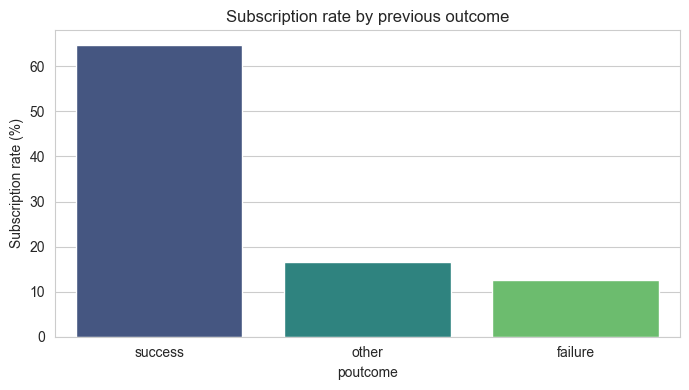

In [18]:
po_rate = df.groupby("poutcome")["y"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 4))
sns.barplot(x=po_rate.index, y=po_rate.values, palette=PALETTE)
plt.ylabel("Subscription rate (%)")
plt.title("Subscription rate by previous outcome")
plt.tight_layout()
plt.show()

### 6.4 Numeric features vs target

We compare subscribers and non-subscribers on a few numeric features. Subscribers tend to have slightly higher balance, while clients contacted many times in the current campaign are less likely to subscribe.

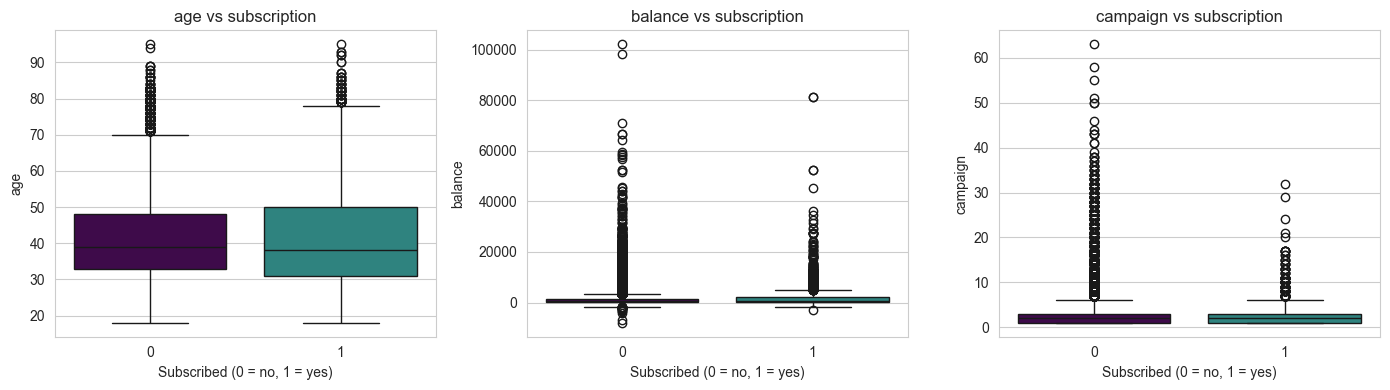

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["age", "balance", "campaign"]):
    sns.boxplot(x="y", y=col, data=df, ax=ax, palette=["#440154", "#21918c"])
    ax.set_title(f"{col} vs subscription")
    ax.set_xlabel("Subscribed (0 = no, 1 = yes)")
plt.tight_layout()
plt.show()

### 6.5 Correlation heatmap

We look at the correlations between numeric features. Most correlations are weak, which is good — it means the features carry different information. The strongest correlations are between `pdays`, `previous`, and `was_contacted_before`, which all describe contact history.

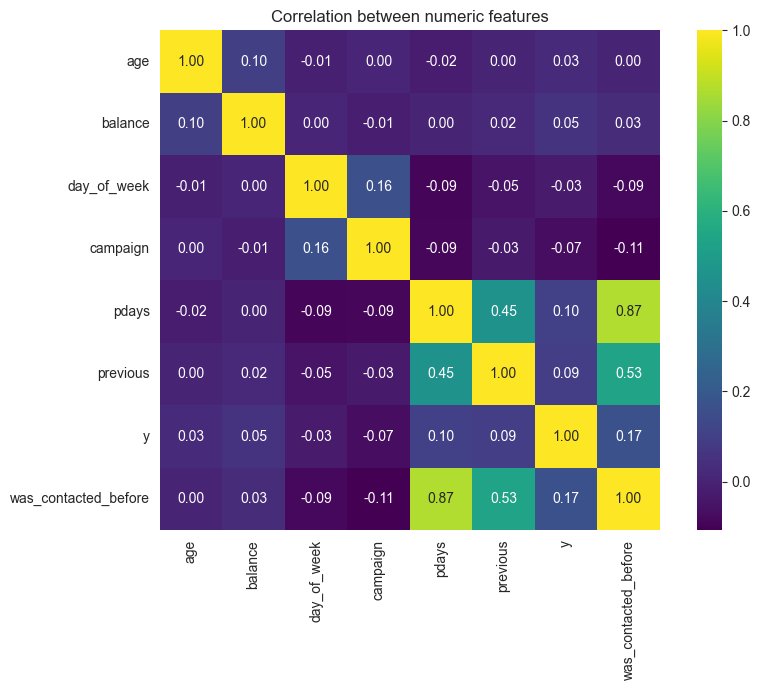

In [20]:
num_only = df.select_dtypes(include=["int64", "float64"])
corr = num_only.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

## 7. Models

We train five models on the training set and check them on the test set.

For each model we record accuracy, precision, recall, F1, ROC-AUC, and training time. We also show the confusion matrix.

In [21]:
results = []        # one row per model, used for the final comparison table
roc_data = {}       # for the combined ROC plot

def evaluate(name, model, Xtr, ytr, Xte, yte):
    start = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - start

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, zero_division=0)
    rec = recall_score(yte, y_pred, zero_division=0)
    f1 = f1_score(yte, y_pred, zero_division=0)
    auc = roc_auc_score(yte, y_proba)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(auc, 4),
        "Train time (s)": round(train_time, 3),
    })

    fpr, tpr, _ = roc_curve(yte, y_proba)
    roc_data[name] = (fpr, tpr, auc)

    print(f"{name}")
    print(f"  Accuracy = {acc:.4f}   Precision = {prec:.4f}   Recall = {rec:.4f}")
    print(f"  F1 = {f1:.4f}   ROC-AUC = {auc:.4f}   Time = {train_time:.2f}s")

    cm = confusion_matrix(yte, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(
        cmap="viridis", ax=ax, colorbar=False
    )
    ax.set_title(f"Confusion matrix — {name}")
    plt.tight_layout()
    plt.show()

    return model

### 7.1 Decision Tree

A decision tree splits the data using simple rules. It is easy to read and to explain.

Without a depth limit, a tree can keep splitting until it memorizes the training data, which causes overfitting. We set `max_depth=6` to keep it under control.

Decision Tree
  Accuracy = 0.8925   Precision = 0.6081   Recall = 0.2277
  F1 = 0.3313   ROC-AUC = 0.6551   Time = 0.08s


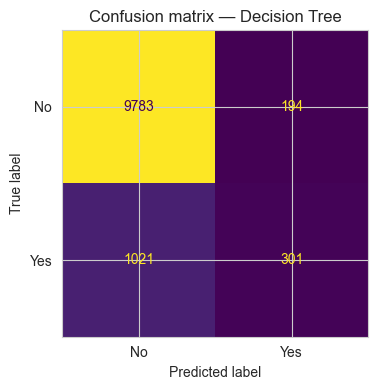

In [22]:
dt = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)
dt = evaluate("Decision Tree", dt, X_train, y_train, X_test, y_test)

We can also draw the top of the tree to see the most important splits.

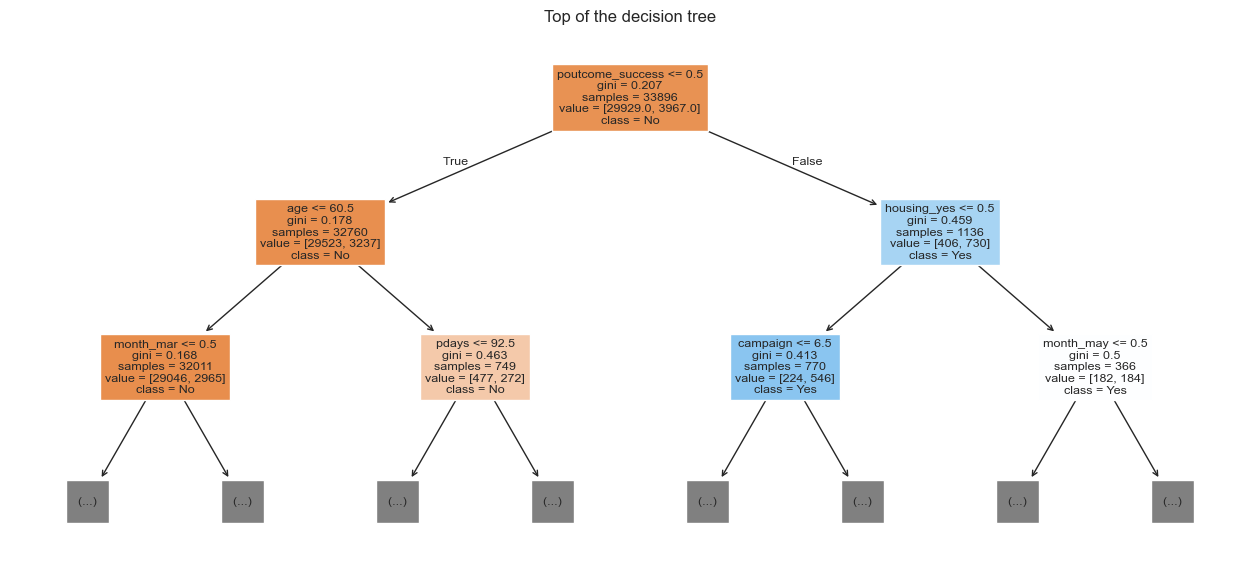

In [23]:
plt.figure(figsize=(16, 7))
plot_tree(dt, max_depth=2, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.title("Top of the decision tree")
plt.show()

### 7.2 Naive Bayes

Naive Bayes is a simple probabilistic classifier. It assumes that the features are independent given the class. This assumption is rarely true in real data, but the method is still fast and reasonable as a baseline.

Naive Bayes
  Accuracy = 0.8563   Precision = 0.3940   Recall = 0.4244
  F1 = 0.4086   ROC-AUC = 0.7358   Time = 0.02s


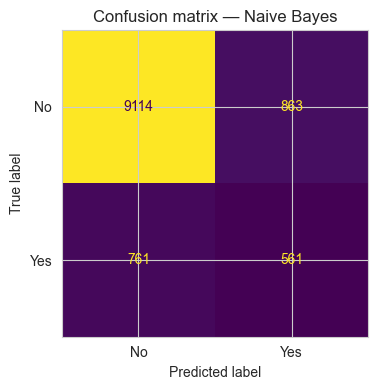

In [24]:
nb = GaussianNB()
nb = evaluate("Naive Bayes", nb, X_train, y_train, X_test, y_test)

### 7.3 k-Nearest Neighbors (k-NN)

k-NN classifies a new sample by looking at its 15 nearest neighbors and taking a majority vote.

Because k-NN works with distances, we use the **scaled** data. Without scaling, features with large values would dominate the distance.

k-NN
  Accuracy = 0.8935   Precision = 0.6325   Recall = 0.2148
  F1 = 0.3207   ROC-AUC = 0.7289   Time = 0.01s


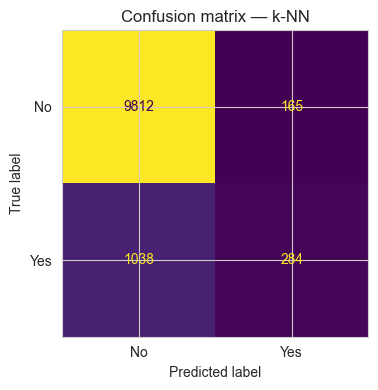

In [25]:
knn = KNeighborsClassifier(n_neighbors=15)
knn = evaluate("k-NN", knn, X_train_scaled, y_train, X_test_scaled, y_test)

### 7.4 Random Forest

Random Forest builds many decision trees on random subsets of the data and combines them by voting. This usually gives better results than a single decision tree and is more stable.

Random Forest
  Accuracy = 0.8936   Precision = 0.6266   Recall = 0.2247
  F1 = 0.3307   ROC-AUC = 0.7714   Time = 1.01s


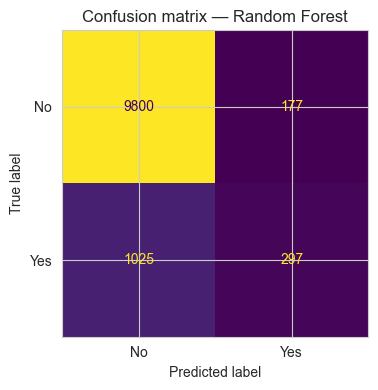

In [26]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf = evaluate("Random Forest", rf, X_train, y_train, X_test, y_test)

### 7.5 Logistic Regression

Logistic Regression is a linear model. It is simple and fast, and the coefficients tell us how each feature affects the prediction. We use the scaled data so the coefficients are comparable.

Logistic Regression
  Accuracy = 0.8937   Precision = 0.6695   Recall = 0.1808
  F1 = 0.2847   ROC-AUC = 0.7538   Time = 0.05s


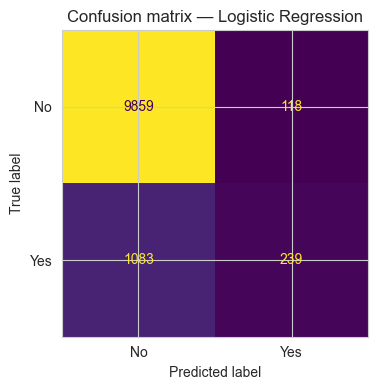

In [27]:
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr = evaluate("Logistic Regression", lr, X_train_scaled, y_train, X_test_scaled, y_test)

### 7.6 Handling the imbalance with class weights

The results above show that most models miss the majority of subscribers (low recall). One simple way to fight this is to use `class_weight="balanced"`, which makes the minority class ("yes") count more during training, so the model is penalized more for missing a subscriber.

Three of our models support this option: Decision Tree, Random Forest, and Logistic Regression. (Naive Bayes and k-NN do not have a class-weight option, so we leave them as they are.) We add the weighted versions as separate models so we can compare them directly with the originals.

Decision Tree (balanced)
  Accuracy = 0.8563   Precision = 0.3893   Recall = 0.4017
  F1 = 0.3954   ROC-AUC = 0.7126   Time = 0.08s


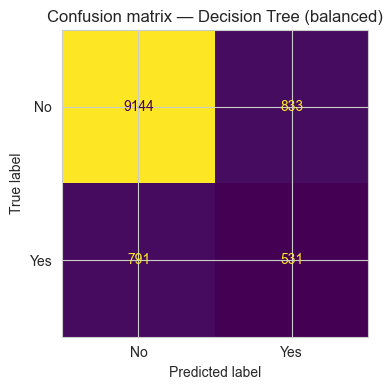

In [28]:
# Decision Tree (balanced)

dt_bal = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)
dt_bal = evaluate("Decision Tree (balanced)", dt_bal, X_train, y_train, X_test, y_test)

Random Forest (balanced)
  Accuracy = 0.8934   Precision = 0.6437   Recall = 0.1982
  F1 = 0.3031   ROC-AUC = 0.7763   Time = 1.00s


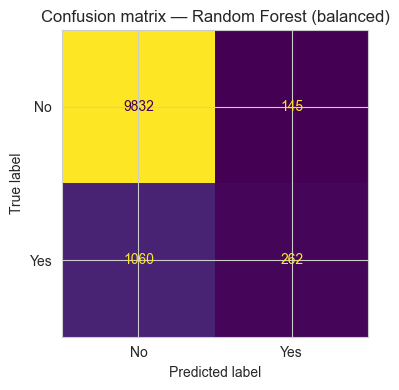

In [29]:
# Random Forest (balanced)

rf_bal = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
rf_bal = evaluate("Random Forest (balanced)", rf_bal, X_train, y_train, X_test, y_test)

Logistic Regression (balanced)
  Accuracy = 0.7573   Precision = 0.2644   Recall = 0.6029
  F1 = 0.3676   ROC-AUC = 0.7542   Time = 0.05s


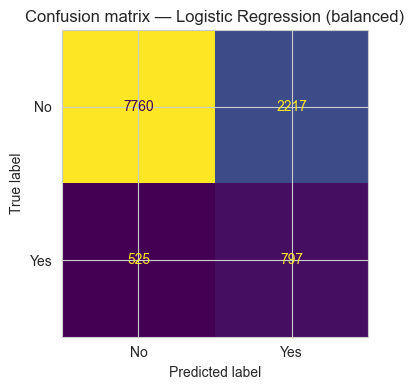

In [30]:
# Logistic Regression (balanced)

lr_bal = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr_bal = evaluate("Logistic Regression (balanced)", lr_bal, X_train_scaled, y_train, X_test_scaled, y_test)

As expected, class weighting changes the balance between precision and recall:

- **Logistic Regression (balanced)** shows the biggest change: its recall jumps from 0.18 to 0.60, so it now finds about 60% of the real subscribers instead of 18%. The cost is that its precision drops from 0.67 to 0.26 and its accuracy drops to about 0.76, because it predicts "yes" much more often.
- **Decision Tree (balanced)** improves on most metrics at once: recall goes from 0.23 to 0.40, F1 goes from 0.33 to 0.40, and ROC-AUC goes from 0.66 to 0.71.
- **Random Forest (balanced)** barely changes, and its F1 actually drops slightly (0.33 to 0.30). For this dataset, class weighting does not help the Random Forest much.

So class weighting is useful, but it is not a magic fix: it mainly trades precision for recall. Whether this trade is worth it depends on the bank's goal.

## 8. Clustering with K-Means

So far we used the target `y` to train classifiers. Now we try **K-Means**, which does not use the target at all. The goal is to group similar clients together based on their numeric features and see what those groups look like.

### 8.1 Choose the number of clusters

We use the **elbow method**: we run K-Means with different values of `k` and look at the inertia (how tightly the points are grouped). The "elbow" of the curve is a good choice for `k`.

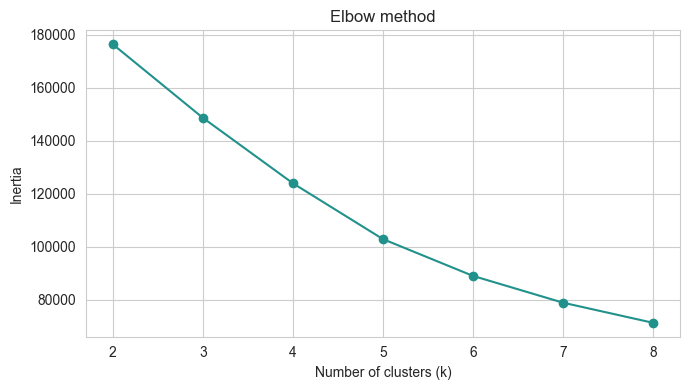

In [31]:
cluster_cols = ["age", "balance", "campaign", "pdays", "previous"]
X_cluster = StandardScaler().fit_transform(df[cluster_cols])

inertias = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, "o-", color="#21918c")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.tight_layout()
plt.show()

### 8.2 Fit K-Means with k = 4

Based on the elbow plot, we pick `k = 4` and assign each client to a cluster. Then we use PCA to project the data to 2D for visualization.

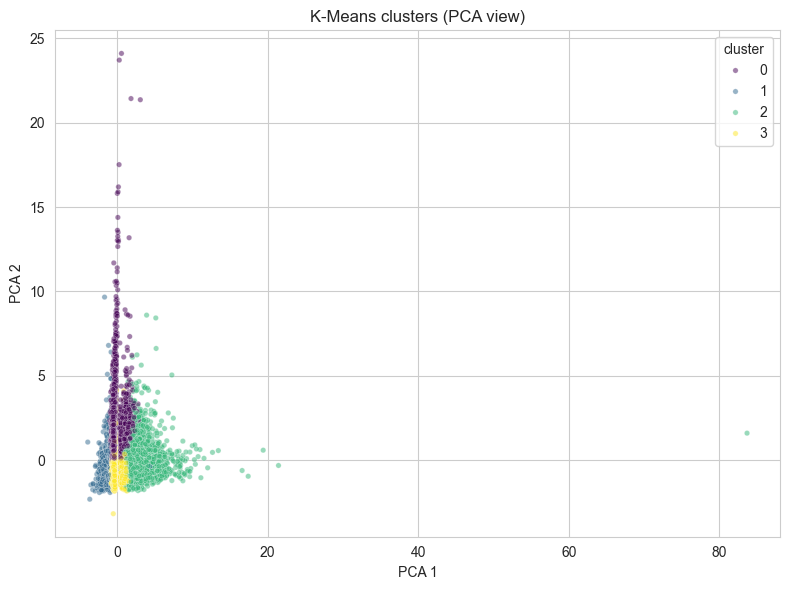

In [32]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["cluster"],
                palette=PALETTE, alpha=0.5, s=15)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means clusters (PCA view)")
plt.tight_layout()
plt.show()

### 8.3 Look at each cluster

For each cluster we compute the mean of the numeric features and the subscription rate. The clusters differ mainly in age, balance, and contact history. The most interesting result is that the cluster of clients who were contacted in a previous campaign (high `pdays` and `previous`) has clearly the highest subscription rate (about 20%), well above the other clusters. The cluster with many contacts in the *current* campaign but little prior history has the lowest rate (about 4%). This shows that having been contacted before is linked to a higher chance of subscribing, while being contacted many times in the current campaign alone is not.

In [33]:
profile = df.groupby("cluster")[cluster_cols].mean().round(2)
profile["subscription_rate_%"] = (df.groupby("cluster")["y"].mean() * 100).round(2)
profile["size"] = df.groupby("cluster").size()
profile

,age,balance,campaign,pdays,previous,subscription_rate_%,size
cluster,,,,,,,
0,52.51,2101.23,2.41,8.37,0.15,11.25,14374
1,40.28,1119.21,14.64,1.09,0.03,4.42,1696
2,39.35,1343.95,2.12,261.57,3.55,19.69,6323
3,34.13,920.56,2.28,3.43,0.07,10.31,22802


## 9. Feature importance

The Random Forest gives us a built-in importance score for each feature: how often the feature is used to split, weighted by how much it improves the split.

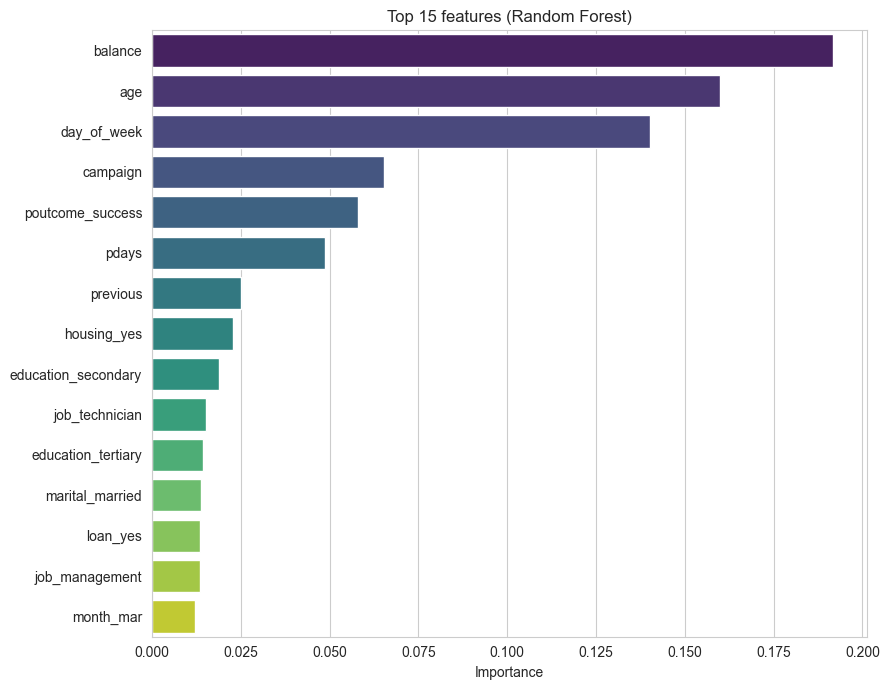

,feature,importance
1,balance,0.191810
0,age,0.159794
2,day_of_week,0.140311
3,campaign,0.065180
37,poutcome_success,0.057945
4,pdays,0.048603
5,previous,0.025200
22,housing_yes,0.022715
19,education_secondary,0.018780
15,job_technician,0.015112


In [34]:
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x="importance", y="feature", data=feat_imp, palette=PALETTE)
plt.title("Top 15 features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

feat_imp

The most important features are `balance`, `age`, and `day_of_week`, followed by `campaign` and `poutcome_success`. So the financial situation and the age of the client are the strongest predictors in the Random Forest, but the success of the previous campaign also appears near the top, which matches what we saw in the EDA (Fig. 3) and in the clusters.

## 10. Model comparison

We now put all the results in one table and compare them visually.

In [35]:
results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train time (s)
0,Naive Bayes,0.8563,0.3940,0.4244,0.4086,0.7358,0.025
1,Decision Tree (balanced),0.8563,0.3893,0.4017,0.3954,0.7126,0.085
2,Logistic Regression (balanced),0.7573,0.2644,0.6029,0.3676,0.7542,0.055
3,Decision Tree,0.8925,0.6081,0.2277,0.3313,0.6551,0.077
4,Random Forest,0.8936,0.6266,0.2247,0.3307,0.7714,1.006
5,k-NN,0.8935,0.6325,0.2148,0.3207,0.7289,0.006
6,Random Forest (balanced),0.8934,0.6437,0.1982,0.3031,0.7763,0.999
7,Logistic Regression,0.8937,0.6695,0.1808,0.2847,0.7538,0.050


### 10.1 Bar chart comparison

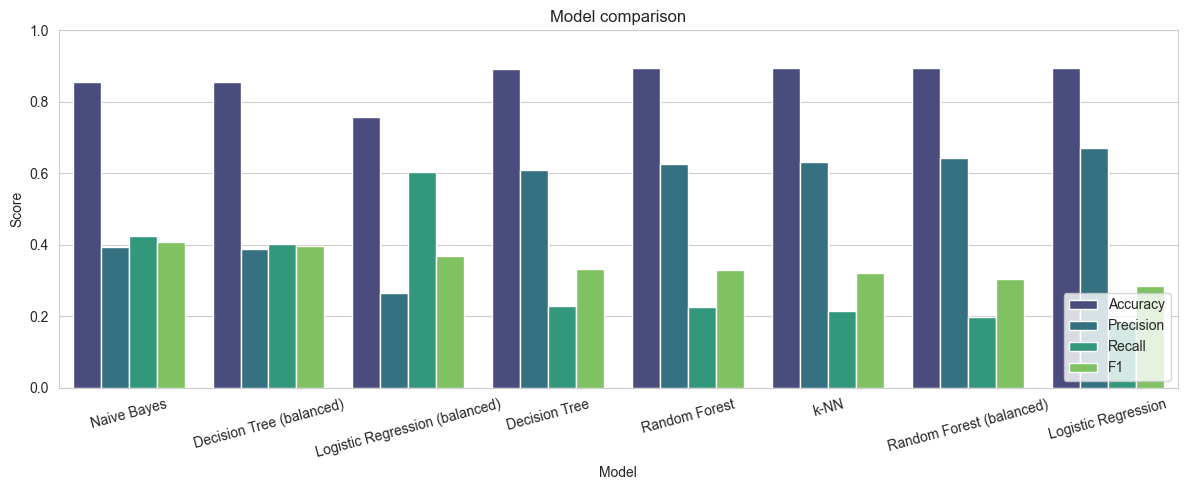

In [36]:
plot_df = results_df.melt(id_vars="Model",
                          value_vars=["Accuracy", "Precision", "Recall", "F1"],
                          var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="Score", hue="Metric", data=plot_df, palette=PALETTE)
plt.title("Model comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 10.2 ROC curves

The ROC curve shows how well each model separates the two classes across all decision thresholds. The closer to the top-left corner, the better.

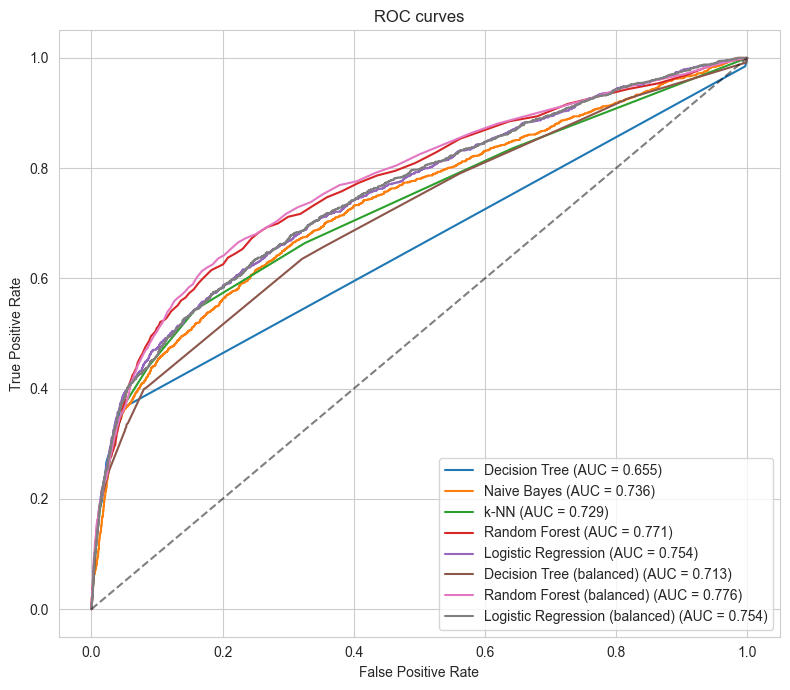

In [37]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Discussion

A few things we noticed:

- All models reach a high **accuracy** of about 89% (except Naive Bayes at 85.6%), but this is misleading because the data is imbalanced (most clients say no). This is why we focus on F1, recall, and ROC-AUC.

- Among the original (unweighted) models, there is **no single best one**. **Naive Bayes** has the best F1 (0.41) and recall (0.42), so it is the best at actually finding subscribers. **Random Forest** has the best ROC-AUC (0.77), so it is the best at ranking clients for a calling list. **Logistic Regression** has the highest precision (0.67) but the lowest recall (0.18). Decision Tree and k-NN sit in between with high accuracy but low recall (around 0.21–0.23).

- **Class weighting clearly helps recall.** When we add `class_weight="balanced"`, Logistic Regression's recall rises from 0.18 to 0.60 and the Decision Tree's recall rises from 0.23 to 0.40. This directly attacks the main weakness of the unweighted models, which was missing most subscribers. The price is lower precision and, for Logistic Regression, lower overall accuracy. Interestingly, the Random Forest did not benefit much from weighting on this dataset.

- Even after weighting the other models, **Naive Bayes still has the best F1 overall** (0.41), which shows it is naturally well suited to this imbalanced problem.

- **k-NN** was the fastest to train (it does not really build a model), while **Random Forest** was the slowest because it builds many trees.

The clustering and the feature importance point in the same direction: **balance, age, and contact history are the strongest signals** in the data.

## 12. Conclusion

We applied five classification models to the Bank Marketing dataset and compared them on the same train/test split, and we also tested class weighting to deal with the imbalance.

The main lesson is that, on an imbalanced dataset, a high accuracy can be misleading: most models reached about 89% accuracy but missed the majority of the real subscribers. When we look at recall and F1, Naive Bayes was the best of the original models at finding subscribers, while Random Forest had the best ROC-AUC and would be the best choice for ranking clients. Adding class weights to the Decision Tree and Logistic Regression greatly increased their recall (Logistic Regression went from finding 18% to 60% of subscribers), at the cost of precision. So the best model depends on the bank's goal, and class weighting is a useful tool when finding subscribers matters more than avoiding false alarms.

Preprocessing was important: handling the `pdays = -1` sentinel, dropping the leaking `duration` column, and scaling the numeric features for the distance-based and linear models.

## 13. Future work

- Compare class weights with **SMOTE** oversampling to see which approach handles the imbalance better.
- Tune the **decision threshold** (instead of using the default 0.5) so the bank can choose its own balance between precision and recall, depending on the cost of missing a subscriber vs. calling a non-subscriber.
- Try **hyperparameter tuning** with `GridSearchCV` for k-NN, Decision Tree, and Random Forest.
- Try other models such as **SVM** or **Gradient Boosting**.